# InaTRC Vehicle Class Classification — Final Full-Data Pipeline

This notebook implements the final classical computer-vision pipeline for classifying Indonesian toll-road vehicle classes I–V on the InaTRC dataset.

The model configuration is fixed in advance. The complete grouped train and validation partitions are combined for fitting, while a leakage-controlled grouped holdout is reserved for reporting. After evaluation, a separate production model is refitted on all retained labelled observations.

## Final pipeline

| Stage | Method |
|---|---|
| Acquisition | InaTRC static CCTV frames and published ground-truth bounding boxes |
| Enhancement | Grayscale conversion and aspect-preserving letterbox normalization |
| Segmentation / ROI isolation | Ground-truth vehicle bounding box; mild contextual padding in the high-resolution branch |
| Feature extraction | HOG at 48×64 and padded HOG at 64×96 |
| Feature representation | Native concatenated HOG vectors (4,032 dimensions) |
| Classification | Tuned LightGBM multiclass classifier with balanced class weights |
| Evaluation | Macro-F1, balanced accuracy, accuracy, per-class metrics, confusion matrix, ROI-size analysis, grouped bootstrap CI |

No deep-learning model, pretrained image embedding, video tracking, temporal predictor, camera ID, frame position, or lane position is used as a classification feature.

## 1. Configuration and dependencies

Place the InaTRC ZIP archive in the same directory as this notebook, or set `DATASET_ZIP` explicitly. Intermediate feature files and final outputs are written to `inatrc_final_workspace/`.

The LightGBM configuration is fixed in this notebook. No hyperparameter search or model selection is performed during execution.

In [1]:
from __future__ import annotations

import hashlib
import json
import logging
import os
import random
import time
import warnings
import zipfile
from functools import lru_cache
from pathlib import Path

import cv2
import h5py
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from threadpoolctl import threadpool_limits
from tqdm import tqdm

# Reproducibility
SEED = 42
CPU_THREADS = 4
random.seed(SEED)
np.random.seed(SEED)
threadpool_limits(limits=CPU_THREADS)
cv2.setNumThreads(CPU_THREADS)

warnings.filterwarnings("ignore", message="X does not have valid feature names, but LGBMClassifier was fitted with feature names")

logging.basicConfig(format="%(asctime)s | %(levelname)s | %(message)s", level=logging.INFO)
LOG = logging.getLogger("inatrc-final")

CLASS_NAMES = ["I", "II", "III", "IV", "V"]
TEMPORAL_WINDOW = 25
EXACT_DUPLICATE_DEDUPLICATION = True

# Final feature configuration
BASE_CANVAS = (48, 64)       # width, height
HIGH_CANVAS = (64, 96)       # width, height
HIGH_PADDING = (0.05, 0.05, 0.05, 0.10)  # left, right, top, bottom

# Final LightGBM configuration
LGB_PARAMS = {
    "n_estimators": 300,
    "num_leaves": 47,
    "max_depth": 11,
    "learning_rate": 0.032795699653185136,
    "min_child_samples": 30,
    "feature_fraction": 0.7942132374212119,
    "bagging_fraction": 0.7422772674924287,
    "bagging_freq": 1,
    "reg_alpha": 0.16172900811143134,
    "reg_lambda": 0.0018869508789698256,
    "min_split_gain": 0.07895095492804138,
}

# Final production refit after holdout evaluation.
REFIT_PRODUCTION_MODEL_ON_ALL_LABELLED_DATA = True

NOTEBOOK_DIR = Path.cwd()
DATASET_ZIP = NOTEBOOK_DIR / "InaTRC Indonesia Toll Road Vehicle Classification Dataset.zip"
if not DATASET_ZIP.exists():
    candidates = sorted(NOTEBOOK_DIR.glob("*InaTRC*.zip"))
    if not candidates:
        candidates = sorted(Path("/mnt/data").glob("*InaTRC*.zip"))
    if not candidates:
        raise FileNotFoundError("InaTRC ZIP archive was not found. Set DATASET_ZIP explicitly.")
    DATASET_ZIP = candidates[0]

WORKDIR = NOTEBOOK_DIR / "inatrc_final_workspace"
DATA_DIR = WORKDIR / "dataset"
CACHE_DIR = WORKDIR / "feature_cache"
OUTPUT_DIR = WORKDIR / "outputs"
MODEL_DIR = WORKDIR / "models"
for directory in (WORKDIR, DATA_DIR, CACHE_DIR, OUTPUT_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

FEATURE_VERSION = "final-hog-v1"
SPLIT_VERSION = "temporal-group-v2.2"

print("Dataset:", DATASET_ZIP)
print("Workspace:", WORKDIR)

Dataset: /home/DSLearning_WSL/Temp/PCD_Finpro/InaTRC Indonesia Toll Road Vehicle Classification Dataset.zip
Workspace: /home/DSLearning_WSL/Temp/PCD_Finpro/inatrc_final_workspace


## 2. Dataset acquisition and annotation manifest

The published YOLO annotations are used only to isolate the vehicle ROI. Bounding boxes that extend slightly beyond the image border are clipped during cropping rather than discarded.

In [2]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(4 * 1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def locate_dataset_root() -> Path:
    expected_name = "InaTRC Indonesia Toll Road Vehicle Classification Dataset"
    candidates = [
        DATA_DIR / expected_name,
        DATASET_ZIP.parent / "inatrc_dataset" / expected_name,
        DATASET_ZIP.parent / "inatrc_full_dataset" / expected_name,
    ]
    for candidate in candidates:
        if (candidate / "train" / "images").is_dir():
            return candidate

    LOG.info("Extracting dataset to %s", DATA_DIR)
    with zipfile.ZipFile(DATASET_ZIP) as archive:
        root = DATA_DIR.resolve()
        for member in archive.infolist():
            destination = (DATA_DIR / member.filename).resolve()
            if not destination.is_relative_to(root):
                raise ValueError(f"Unsafe ZIP member: {member.filename}")
        archive.extractall(DATA_DIR)

    for candidate in DATA_DIR.rglob("train"):
        if (candidate / "images").is_dir() and (candidate / "labels").is_dir():
            return candidate.parent
    raise FileNotFoundError("Could not locate the extracted InaTRC dataset root.")


DATA_SHA256 = sha256_file(DATASET_ZIP)
DATA_TAG = DATA_SHA256[:12]
DATASET_ROOT = locate_dataset_root()
MANIFEST_PATH = WORKDIR / f"manifest_{DATA_TAG}.joblib"

if MANIFEST_PATH.exists():
    frames, objects = joblib.load(MANIFEST_PATH)
    if not frames["path"].map(lambda p: Path(p).exists()).all():
        MANIFEST_PATH.unlink()

if not MANIFEST_PATH.exists():
    frame_rows = []
    object_rows = []

    for split in ("train", "val", "test"):
        image_dir = DATASET_ROOT / split / "images"
        label_dir = DATASET_ROOT / split / "labels"

        for image_path in sorted(image_dir.glob("*.jpg")):
            frame_id = int(image_path.stem)
            image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
            if image is None:
                raise ValueError(f"Unreadable image: {image_path}")
            height, width = image.shape

            label_path = label_dir / f"{image_path.stem}.txt"
            if not label_path.exists():
                raise FileNotFoundError(f"Missing annotation: {label_path}")

            lines = [line.split() for line in label_path.read_text().splitlines() if line.strip()]
            frame_rows.append((frame_id, split, str(image_path), width, height, len(lines)))

            for obj_idx, tokens in enumerate(lines):
                if len(tokens) != 5:
                    raise ValueError(f"Malformed YOLO label in {label_path}: {tokens}")

                class_id = int(tokens[0])
                xc, yc, bw, bh = map(float, tokens[1:])
                if class_id not in range(5):
                    raise ValueError(f"Unexpected class ID {class_id} in {label_path}")
                if not (0 <= xc <= 1 and 0 <= yc <= 1 and 0 < bw <= 1 and 0 < bh <= 1):
                    raise ValueError(f"Invalid normalized bounding box in {label_path}")

                x1 = (xc - bw / 2) * width
                y1 = (yc - bh / 2) * height
                x2 = (xc + bw / 2) * width
                y2 = (yc + bh / 2) * height
                object_rows.append(
                    (frame_id, obj_idx, split, class_id, xc, yc, bw, bh, x1, y1, x2, y2, width, height)
                )

    frames = pd.DataFrame(
        frame_rows,
        columns=["frame_id", "official_split", "path", "frame_w", "frame_h", "n_objects"],
    ).sort_values("frame_id").reset_index(drop=True)

    objects = pd.DataFrame(
        object_rows,
        columns=[
            "frame_id", "obj_idx", "official_split", "class_id", "xc", "yc", "bw", "bh",
            "x1", "y1", "x2", "y2", "frame_w", "frame_h",
        ],
    ).sort_values(["frame_id", "obj_idx"]).reset_index(drop=True)

    joblib.dump((frames, objects), MANIFEST_PATH, compress=3)

objects = objects.sort_values(["frame_id", "obj_idx"]).reset_index(drop=True)
objects["roi_id"] = np.arange(len(objects), dtype=np.int32)
objects["bbox_w_px"] = objects["bw"] * objects["frame_w"]
objects["bbox_h_px"] = objects["bh"] * objects["frame_h"]
objects["min_dim_px"] = objects[["bbox_w_px", "bbox_h_px"]].min(axis=1)

assert frames["frame_id"].is_unique
assert objects[["frame_id", "obj_idx"]].drop_duplicates().shape[0] == len(objects)
assert set(objects["class_id"].unique()) == set(range(5))

print(f"Archive SHA-256: {DATA_SHA256}")
print(f"Frames: {len(frames):,}")
print(f"Annotated vehicle ROIs: {len(objects):,}")
display(pd.crosstab(objects["class_id"], objects["official_split"]).rename(index=dict(enumerate(CLASS_NAMES))))

2026-09-25 05:53:55,100 | INFO | Extracting dataset to /home/DSLearning_WSL/Temp/PCD_Finpro/inatrc_final_workspace/dataset


Archive SHA-256: 98ca8df90167a525eb60e123f8b31c33d16486b13d9f13a812dc3af9eb39b860
Frames: 3,250
Annotated vehicle ROIs: 34,408


official_split,test,train,val
class_id,,,
I,2131,16384,2219
II,1167,7683,1103
III,236,2154,262
IV,42,316,54
V,66,526,65


## 3. Leakage-controlled grouped split

Frame IDs are sequential in the dataset and many neighbouring frames depict nearly identical CCTV content. The evaluation split therefore groups temporally adjacent and visually near-duplicate frames before partitioning.

Grouping uses:

- exact JPEG MD5 identity;
- adjacent-frame grayscale correlation ≥ 0.98;
- contiguous 25-frame windows within a coarse scene segment;
- deterministic group-level train/validation/test assignment;
- removal of training boundary frames with adjacent cross-split correlation ≥ 0.95.

These variables are used only to construct the split; none are classification features.

In [3]:
def build_leakage_groups(frames: pd.DataFrame):
    cache_path = WORKDIR / f"leakage_{DATA_TAG}_w{TEMPORAL_WINDOW}_{SPLIT_VERSION}.joblib"
    if cache_path.exists():
        return joblib.load(cache_path)

    md5_hashes = []
    thumbnails = []
    for row in tqdm(frames.itertuples(index=False), total=len(frames), desc="Frame audit"):
        md5_hashes.append(hashlib.md5(Path(row.path).read_bytes()).hexdigest())
        gray = cv2.imread(row.path, cv2.IMREAD_GRAYSCALE)
        thumbnails.append(cv2.resize(gray, (96, 64), interpolation=cv2.INTER_AREA))

    leak = frames[["frame_id", "official_split", "frame_w", "frame_h"]].copy()
    leak["md5"] = md5_hashes

    a = np.stack(thumbnails[:-1]).astype(np.float32)
    b = np.stack(thumbnails[1:]).astype(np.float32)
    aa = a - a.mean(axis=(1, 2), keepdims=True)
    bb = b - b.mean(axis=(1, 2), keepdims=True)
    corr = (aa * bb).sum(axis=(1, 2)) / np.sqrt(
        (aa * aa).sum(axis=(1, 2)) * (bb * bb).sum(axis=(1, 2)) + 1e-9
    )

    adjacent = pd.DataFrame({
        "a": leak["frame_id"].to_numpy()[:-1],
        "b": leak["frame_id"].to_numpy()[1:],
        "corr": corr,
        "same_resolution": (
            (leak["frame_w"].to_numpy()[:-1] == leak["frame_w"].to_numpy()[1:])
            & (leak["frame_h"].to_numpy()[:-1] == leak["frame_h"].to_numpy()[1:])
        ),
    })
    adjacent["consecutive"] = adjacent["b"] == adjacent["a"] + 1

    scene_boundary = (
        (~adjacent["same_resolution"])
        | (~adjacent["consecutive"])
        | (adjacent["corr"] < 0.40)
    ).to_numpy()
    leak["scene_id"] = np.r_[0, np.cumsum(scene_boundary)].astype(int)
    scene_start = leak.groupby("scene_id")["frame_id"].transform("min")
    leak["window_in_scene"] = ((leak["frame_id"] - scene_start) // TEMPORAL_WINDOW).astype(int)

    parent = {int(frame_id): int(frame_id) for frame_id in leak["frame_id"]}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        rx, ry = find(int(x)), find(int(y))
        if rx != ry:
            parent[ry] = rx

    for _, subset in leak.groupby("md5"):
        ids = subset["frame_id"].tolist()
        for frame_id in ids[1:]:
            union(ids[0], frame_id)

    for row in adjacent.itertuples(index=False):
        if row.consecutive and row.same_resolution and row.corr >= 0.98:
            union(row.a, row.b)

    for _, subset in leak.groupby(["scene_id", "window_in_scene"]):
        ids = subset["frame_id"].tolist()
        for frame_id in ids[1:]:
            union(ids[0], frame_id)

    root_to_group = {}
    for frame_id in leak["frame_id"]:
        root = find(int(frame_id))
        root_to_group.setdefault(root, len(root_to_group))
    leak["group"] = leak["frame_id"].map(lambda x: root_to_group[find(int(x))]).astype(int)

    joblib.dump((leak, adjacent), cache_path, compress=3)
    return leak, adjacent


def optimize_fixed_group_split(group_stats: pd.DataFrame, tries=80, seed=SEED):
    group_ids = group_stats.index.to_numpy()
    frame_counts = group_stats["nframes"].to_numpy()
    class_counts = group_stats[[f"c{i}" for i in range(5)]].to_numpy(dtype=float)

    total_frames = frame_counts.sum()
    total_classes = class_counts.sum(axis=0)
    class_prior = total_classes / total_classes.sum()
    best = None

    for attempt in range(tries):
        rng = np.random.RandomState(seed + attempt)
        order = rng.permutation(len(group_ids))
        assignment = np.full(len(group_ids), "train", dtype=object)
        test_frames = 0
        val_frames = 0

        for idx in order:
            if test_frames < total_frames * 0.10:
                assignment[idx] = "test"
                test_frames += frame_counts[idx]
            elif val_frames < total_frames * 0.10:
                assignment[idx] = "val"
                val_frames += frame_counts[idx]

        ratios = np.array([
            frame_counts[assignment == split].sum() / total_frames
            for split in ("train", "val", "test")
        ])
        score = 8 * np.mean(np.abs(ratios - np.array([0.8, 0.1, 0.1])))
        feasible = True

        for split in ("train", "val", "test"):
            counts = class_counts[assignment == split].sum(axis=0)
            if (counts < 1).any():
                feasible = False
                score += 1000
            prior = counts / max(counts.sum(), 1)
            score += np.mean(np.abs(prior - class_prior) / np.sqrt(class_prior + 0.005))
            score += 0.05 * np.mean(np.abs(prior - class_prior))

        if best is None or score < best[0]:
            best = (score, assignment.copy(), feasible)

    if not best[2]:
        raise RuntimeError("Unable to construct a class-complete grouped split.")
    return pd.DataFrame({"group": group_ids, "experimental_split": best[1]})


leak, adjacent = build_leakage_groups(frames)

frame_class_counts = (
    objects.groupby(["frame_id", "class_id"]).size().unstack(fill_value=0).reindex(columns=range(5), fill_value=0)
)
frame_meta = leak[["frame_id", "group", "scene_id", "md5"]].merge(
    frame_class_counts, left_on="frame_id", right_index=True, how="left"
).fillna(0)

group_stats = frame_meta.groupby("group").agg(
    nframes=("frame_id", "size"),
    **{f"c{i}": (i, "sum") for i in range(5)},
)

split_path = WORKDIR / f"group_split_{DATA_TAG}_w{TEMPORAL_WINDOW}_{SPLIT_VERSION}.csv"
if split_path.exists():
    split_groups = pd.read_csv(split_path)
else:
    split_groups = optimize_fixed_group_split(group_stats)
    split_groups.to_csv(split_path, index=False)

split_map = leak[["frame_id", "group", "scene_id", "md5"]].merge(
    split_groups, on="group", validate="many_to_one"
)

assert split_map.groupby("group")["experimental_split"].nunique().max() == 1
assert split_map.groupby("md5")["experimental_split"].nunique().max() == 1

work = objects.merge(split_map, on="frame_id", validate="many_to_one")

if EXACT_DUPLICATE_DEDUPLICATION:
    canonical_frames = set(split_map.groupby("md5")["frame_id"].min().values)
    work = work[work["frame_id"].isin(canonical_frames)].copy()

frame_to_split = split_map.set_index("frame_id")["experimental_split"].to_dict()
purge_frames = set()
for row in adjacent.itertuples(index=False):
    if not (row.consecutive and row.same_resolution and row.corr >= 0.95):
        continue
    split_a = frame_to_split[row.a]
    split_b = frame_to_split[row.b]
    if split_a != split_b:
        if split_a == "train":
            purge_frames.add(row.a)
        if split_b == "train":
            purge_frames.add(row.b)

work = work[
    ~((work["experimental_split"] == "train") & work["frame_id"].isin(purge_frames))
].copy().reset_index(drop=True)

# Verify that no retained exact duplicate or leakage group crosses a split.
assert work.groupby("group")["experimental_split"].nunique().max() == 1
assert work.groupby("md5")["experimental_split"].nunique().max() == 1

retained_frames = set(work["frame_id"].unique())
remaining_close_pairs = []
for row in adjacent.itertuples(index=False):
    if not (row.consecutive and row.same_resolution and row.corr >= 0.95):
        continue
    if row.a in retained_frames and row.b in retained_frames and frame_to_split[row.a] != frame_to_split[row.b]:
        remaining_close_pairs.append((row.a, row.b, row.corr))
assert not remaining_close_pairs, f"Residual high-similarity cross-split pairs: {remaining_close_pairs[:5]}"

print(f"Leakage groups: {leak['group'].nunique()}")
print(f"Purged training boundary frames: {len(purge_frames)}")
display(pd.crosstab(work["class_id"], work["experimental_split"]).rename(index=dict(enumerate(CLASS_NAMES))))

Frame audit: 100%|██████████| 3250/3250 [00:06<00:00, 541.28it/s]


Leakage groups: 119
Purged training boundary frames: 9


experimental_split,test,train,val
class_id,,,
I,2749,15598,1948
II,1367,7506,942
III,351,2036,225
IV,52,308,51
V,84,463,81


## 4. Full-data evaluation protocol

The model configuration is already fixed. The original grouped **train and validation partitions are combined** for fitting, so every retained training observation contributes to the evaluation model. The grouped test partition remains untouched until prediction.

After reporting holdout performance, an optional production refit uses all retained labelled observations.

In [4]:
fit_rows = work[work["experimental_split"].isin(["train", "val"])].sort_values("roi_id").reset_index(drop=True)
test_rows = work[work["experimental_split"] == "test"].sort_values("roi_id").reset_index(drop=True)

assert set(fit_rows["group"]).isdisjoint(set(test_rows["group"]))
assert set(fit_rows["md5"]).isdisjoint(set(test_rows["md5"]))

print(f"Fit ROIs (train + validation): {len(fit_rows):,}")
print(f"Holdout ROIs: {len(test_rows):,}")
print(f"Fit frames: {fit_rows['frame_id'].nunique():,}")
print(f"Holdout frames: {test_rows['frame_id'].nunique():,}")
print(f"Fit groups: {fit_rows['group'].nunique():,}")
print(f"Holdout groups: {test_rows['group'].nunique():,}")

display(pd.DataFrame({
    "fit": fit_rows["class_id"].value_counts().sort_index(),
    "holdout": test_rows["class_id"].value_counts().sort_index(),
}).rename(index=dict(enumerate(CLASS_NAMES))))

Fit ROIs (train + validation): 29,158
Holdout ROIs: 4,603
Fit frames: 2,839
Holdout frames: 330
Fit groups: 106
Holdout groups: 13


,fit,holdout
class_id,,
I,17546,2749
II,8448,1367
III,2261,351
IV,359,52
V,544,84


## 5. Preprocessing and final HOG representation

Two complementary HOG branches are extracted from each vehicle:

1. **Base branch:** exact ground-truth ROI → 48×64 letterbox → HOG.
2. **Context branch:** ROI expanded by 5% left/right/top and 10% bottom → 64×96 letterbox → HOG.

Both branches preserve aspect ratio and use the crop median as the padding value. No additional intensity enhancement or feature scaling is applied.

In [5]:
FRAME_PATHS = frames.set_index("frame_id")["path"].to_dict()

@lru_cache(maxsize=64)
def read_gray_frame(frame_id: int) -> np.ndarray:
    image = cv2.imread(FRAME_PATHS[int(frame_id)], cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(FRAME_PATHS[int(frame_id)])
    return image


def crop_vehicle(row, padding=(0.0, 0.0, 0.0, 0.0)) -> np.ndarray:
    image = read_gray_frame(int(row.frame_id))
    height, width = image.shape

    bbox_w = max(1.0, row.x2 - row.x1)
    bbox_h = max(1.0, row.y2 - row.y1)
    pad_left, pad_right, pad_top, pad_bottom = padding

    x1 = max(0, int(np.floor(row.x1 - pad_left * bbox_w)))
    x2 = min(width, int(np.ceil(row.x2 + pad_right * bbox_w)))
    y1 = max(0, int(np.floor(row.y1 - pad_top * bbox_h)))
    y2 = min(height, int(np.ceil(row.y2 + pad_bottom * bbox_h)))

    if x2 <= x1 or y2 <= y1:
        return np.zeros((2, 2), dtype=np.uint8)
    return image[y1:y2, x1:x2]


def letterbox(gray: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    target_w, target_h = size
    height, width = gray.shape
    scale = min(target_w / width, target_h / height)

    new_w = max(1, round(width * scale))
    new_h = max(1, round(height * scale))
    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(gray, (new_w, new_h), interpolation=interpolation)

    canvas = np.full((target_h, target_w), int(np.median(gray)), dtype=np.uint8)
    x0 = (target_w - new_w) // 2
    y0 = (target_h - new_h) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas


HOG_BASE = cv2.HOGDescriptor(BASE_CANVAS, (16, 16), (8, 8), (8, 8), 9)
HOG_HIGH = cv2.HOGDescriptor(HIGH_CANVAS, (16, 16), (8, 8), (8, 8), 9)

BASE_DIM = int(HOG_BASE.getDescriptorSize())
HIGH_DIM = int(HOG_HIGH.getDescriptorSize())
FEATURE_DIM = BASE_DIM + HIGH_DIM


def extract_feature(row, branch: str) -> np.ndarray:
    if branch == "hog_base":
        crop = crop_vehicle(row)
        return HOG_BASE.compute(letterbox(crop, BASE_CANVAS)).ravel().astype(np.float32)
    if branch == "hog_high_padded":
        crop = crop_vehicle(row, HIGH_PADDING)
        return HOG_HIGH.compute(letterbox(crop, HIGH_CANVAS)).ravel().astype(np.float32)
    raise ValueError(f"Unknown feature branch: {branch}")


sample = fit_rows.iloc[0]
assert extract_feature(sample, "hog_base").shape == (BASE_DIM,)
assert extract_feature(sample, "hog_high_padded").shape == (HIGH_DIM,)

print(f"Base HOG dimensions: {BASE_DIM}")
print(f"Padded high-resolution HOG dimensions: {HIGH_DIM}")
print(f"Final feature dimensions: {FEATURE_DIM}")

Base HOG dimensions: 1260
Padded high-resolution HOG dimensions: 2772
Final feature dimensions: 4032


## 6. Resumable feature cache

Feature extraction is deterministic. Each HOG branch is cached by global ROI ID in an append-only HDF5 file so interrupted runs can resume without recomputing completed ROIs.

In [6]:
BRANCH_DIMS = {
    "hog_base": BASE_DIM,
    "hog_high_padded": HIGH_DIM,
}


def feature_cache_path(branch: str) -> Path:
    signature = hashlib.sha256(json.dumps({
        "branch": branch,
        "data": DATA_TAG,
        "version": FEATURE_VERSION,
        "base_canvas": BASE_CANVAS,
        "high_canvas": HIGH_CANVAS,
        "high_padding": HIGH_PADDING,
    }, sort_keys=True).encode()).hexdigest()[:16]
    return CACHE_DIR / f"{branch}_{signature}.h5"


def feature_bank(branch: str, rows: pd.DataFrame) -> np.ndarray:
    dim = BRANCH_DIMS[branch]
    requested_ids = rows["roi_id"].to_numpy(dtype=np.int64)
    if len(np.unique(requested_ids)) != len(requested_ids):
        raise ValueError("ROI IDs must be unique in a feature request.")

    path = feature_cache_path(branch)
    with h5py.File(path, "a") as handle:
        if "ids" not in handle:
            handle.create_dataset("ids", shape=(0,), maxshape=(None,), dtype="i4", chunks=(256,))
            handle.create_dataset(
                "values", shape=(0, dim), maxshape=(None, dim), dtype="f4",
                chunks=(64, dim), compression="lzf",
            )
            handle.attrs["branch"] = branch
            handle.attrs["dim"] = dim
            handle.attrs["feature_version"] = FEATURE_VERSION
            handle.attrs["data_tag"] = DATA_TAG

        ids_ds = handle["ids"]
        values_ds = handle["values"]
        if values_ds.shape[1] != dim:
            raise RuntimeError("Feature cache dimension mismatch.")

        stored_ids = ids_ds[:]
        position = {int(roi_id): idx for idx, roi_id in enumerate(stored_ids) if roi_id >= 0}
        missing = [int(roi_id) for roi_id in requested_ids if int(roi_id) not in position]

        if missing:
            LOG.info("%s: extracting %d new ROIs", branch, len(missing))
            subset = objects.iloc[missing].sort_values(["frame_id", "obj_idx"])
            batch_ids = []
            batch_values = []

            def flush_batch():
                if not batch_ids:
                    return
                start = len(ids_ds)
                count = len(batch_ids)
                ids_ds.resize((start + count,))
                values_ds.resize((start + count, dim))
                ids_ds[start:start + count] = -1
                values_ds[start:start + count] = np.stack(batch_values).astype(np.float32)
                ids_ds[start:start + count] = np.asarray(batch_ids, dtype=np.int32)
                handle.flush()
                for offset, roi_id in enumerate(batch_ids):
                    position[int(roi_id)] = start + offset
                batch_ids.clear()
                batch_values.clear()

            for row in tqdm(subset.itertuples(index=False), total=len(subset), desc=branch):
                vector = extract_feature(row, branch)
                if vector.shape != (dim,) or not np.isfinite(vector).all():
                    raise ValueError(f"Invalid {branch} feature for ROI {row.roi_id}")
                batch_ids.append(int(row.roi_id))
                batch_values.append(vector)
                if len(batch_ids) >= 64:
                    flush_batch()
            flush_batch()

        positions = np.asarray([position[int(roi_id)] for roi_id in requested_ids], dtype=np.int64)
        order = np.argsort(positions)
        sorted_positions = positions[order]
        sorted_values = values_ds[sorted_positions]
        output = np.empty((len(requested_ids), dim), dtype=np.float32)
        output[order] = sorted_values
        return output


def build_feature_matrix(rows: pd.DataFrame) -> np.ndarray:
    base = feature_bank("hog_base", rows)
    high = feature_bank("hog_high_padded", rows)
    matrix = np.concatenate([base, high], axis=1).astype(np.float32, copy=False)
    assert matrix.shape == (len(rows), FEATURE_DIM)
    assert np.isfinite(matrix).all()
    return matrix

## 7. Fit the final evaluation model

Class imbalance is handled with inverse-frequency class weights computed from the complete fitting partition. The HOG features are supplied directly to LightGBM without global scaling or dimensionality reduction.

In [7]:
def balanced_class_weights(y: np.ndarray) -> dict[int, float]:
    classes, counts = np.unique(y, return_counts=True)
    n = len(y)
    k = len(classes)
    return {int(cls): float(n / (k * count)) for cls, count in zip(classes, counts)}


def make_final_model(y: np.ndarray) -> LGBMClassifier:
    return LGBMClassifier(
        **LGB_PARAMS,
        class_weight=balanced_class_weights(y),
        objective="multiclass",
        num_class=5,
        verbosity=-1,
        n_jobs=CPU_THREADS,
        random_state=SEED,
    )


start = time.time()
X_fit = build_feature_matrix(fit_rows)
X_test = build_feature_matrix(test_rows)
y_fit = fit_rows["class_id"].to_numpy(dtype=int)
y_test = test_rows["class_id"].to_numpy(dtype=int)

print(f"Fit matrix: {X_fit.shape} ({X_fit.nbytes / 1024**2:.1f} MiB)")
print(f"Holdout matrix: {X_test.shape} ({X_test.nbytes / 1024**2:.1f} MiB)")

model = make_final_model(y_fit)
model.fit(X_fit, y_fit)
test_proba = model.predict_proba(X_test)
test_pred = np.argmax(test_proba, axis=1)
print(f"Feature extraction + fitting completed in {(time.time() - start) / 60:.1f} minutes")

2026-09-25 05:54:15,367 | INFO | hog_base: extracting 29158 new ROIs
hog_base: 100%|██████████| 29158/29158 [00:11<00:00, 2624.08it/s]
2026-09-25 05:54:27,256 | INFO | hog_high_padded: extracting 29158 new ROIs
hog_high_padded: 100%|██████████| 29158/29158 [00:13<00:00, 2108.68it/s]
2026-09-25 05:54:43,179 | INFO | hog_base: extracting 4603 new ROIs
hog_base:   7%|▋         | 304/4603 [00:00<00:01, 3035.69it/s]

Feature extraction + fitting completed in 8.9 minutes


## 8. Holdout evaluation

Macro-F1 is the primary metric because the class distribution is strongly imbalanced. Balanced accuracy, overall accuracy, and per-class precision/recall/F1 are reported as complementary measures.

In [8]:
def metric_summary(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[dict, pd.DataFrame]:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(5), zero_division=0
    )
    summary = {
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", labels=range(5), zero_division=0)),
        "balanced_accuracy": float(recall.mean()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    per_class = pd.DataFrame({
        "class": CLASS_NAMES,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support.astype(int),
    })
    return summary, per_class


summary, per_class = metric_summary(y_test, test_pred)
summary_table = pd.DataFrame([summary])

display(summary_table.round(4))
display(per_class.round(4))
print(classification_report(y_test, test_pred, labels=range(5), target_names=CLASS_NAMES, zero_division=0))

predictions = test_rows[["roi_id", "frame_id", "obj_idx", "group", "class_id", "bbox_w_px", "bbox_h_px"]].copy()
predictions = predictions.rename(columns={"class_id": "y_true"})
predictions["y_pred"] = test_pred
for class_id, class_name in enumerate(CLASS_NAMES):
    predictions[f"p_{class_name}"] = test_proba[:, class_id]
predictions.to_csv(OUTPUT_DIR / "grouped_holdout_predictions.csv", index=False)

summary_table.to_csv(OUTPUT_DIR / "holdout_summary.csv", index=False)
per_class.to_csv(OUTPUT_DIR / "holdout_per_class.csv", index=False)

,macro_f1,balanced_accuracy,accuracy
0,0.6045,0.554,0.8581


,class,precision,recall,f1,support
0,I,0.9570,0.9305,0.9436,2749
1,II,0.7449,0.8800,0.8068,1367
2,III,0.5539,0.4245,0.4806,351
3,IV,0.8000,0.1538,0.2581,52
4,V,0.8889,0.3810,0.5333,84


              precision    recall  f1-score   support

           I       0.96      0.93      0.94      2749
          II       0.74      0.88      0.81      1367
         III       0.55      0.42      0.48       351
          IV       0.80      0.15      0.26        52
           V       0.89      0.38      0.53        84

    accuracy                           0.86      4603
   macro avg       0.79      0.55      0.60      4603
weighted avg       0.86      0.86      0.85      4603



,I,II,III,IV,V
I,2558,177,14,0,0
II,88,1203,73,2,1
III,15,186,149,0,1
IV,4,19,19,8,2
V,8,30,14,0,32


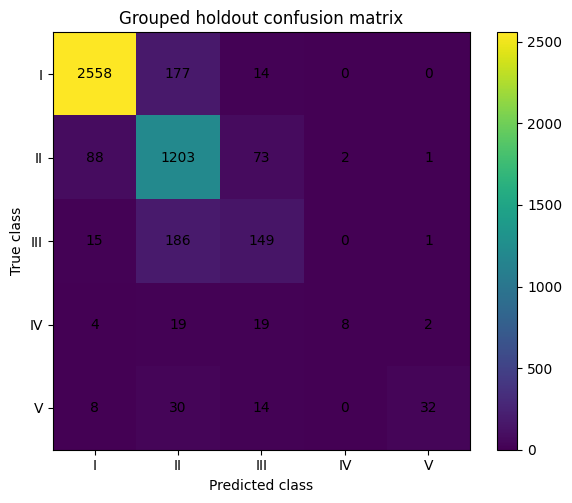

In [9]:
cm = confusion_matrix(y_test, test_pred, labels=range(5))
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
display(cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()
plt.xticks(range(5), CLASS_NAMES)
plt.yticks(range(5), CLASS_NAMES)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Grouped holdout confusion matrix")
for row in range(5):
    for col in range(5):
        plt.text(col, row, str(cm[row, col]), ha="center", va="center")
plt.tight_layout()
plt.show()

## 9. Performance by ROI size

The minimum bounding-box dimension is used as a simple image-information proxy. The model is not retrained for any size stratum; the table below partitions the same holdout predictions.

In [10]:
analysis = predictions.copy()
analysis["min_dim_px"] = analysis[["bbox_w_px", "bbox_h_px"]].min(axis=1)
analysis["size_bin"] = pd.cut(
    analysis["min_dim_px"],
    bins=[-np.inf, 24, 32, 48, np.inf],
    labels=["<24", "24–31", "32–47", "≥48"],
    right=False,
)

size_rows = []
for size_bin, subset in analysis.groupby("size_bin", observed=True):
    metrics_row, _ = metric_summary(subset["y_true"].to_numpy(), subset["y_pred"].to_numpy())
    size_rows.append({"size_bin": str(size_bin), "n": len(subset), **metrics_row})

size_table = pd.DataFrame(size_rows)
display(size_table.round(4))
size_table.to_csv(OUTPUT_DIR / "holdout_by_roi_size.csv", index=False)

,size_bin,n,macro_f1,balanced_accuracy,accuracy
0,<24,1801,0.3610,0.3640,0.9006
1,24–31,779,0.3902,0.3994,0.8408
2,32–47,823,0.5579,0.5180,0.8445
3,≥48,1200,0.6723,0.6268,0.8150


## 10. Grouped bootstrap confidence interval

Vehicle ROIs from the same temporal group are correlated. Uncertainty is therefore estimated by resampling **groups**, not individual ROIs. The reported interval is a percentile bootstrap interval for holdout Macro-F1.

In [11]:
def grouped_bootstrap_macro_f1(prediction_frame: pd.DataFrame, n_boot=1000, seed=SEED):
    data = prediction_frame.reset_index(drop=True)
    group_indices = list(data.groupby("group").indices.values())
    rng = np.random.RandomState(seed)
    samples = []

    for _ in range(n_boot):
        selected_groups = rng.randint(0, len(group_indices), size=len(group_indices))
        indices = np.concatenate([group_indices[idx] for idx in selected_groups])
        score = f1_score(
            data["y_true"].to_numpy()[indices],
            data["y_pred"].to_numpy()[indices],
            labels=range(5),
            average="macro",
            zero_division=0,
        )
        samples.append(score)

    samples = np.asarray(samples)
    return {
        "estimate": summary["macro_f1"],
        "ci_95_low": float(np.percentile(samples, 2.5)),
        "ci_95_high": float(np.percentile(samples, 97.5)),
        "n_groups": len(group_indices),
        "n_bootstrap": n_boot,
    }


bootstrap_result = grouped_bootstrap_macro_f1(predictions, n_boot=1000)
bootstrap_table = pd.DataFrame([bootstrap_result])
display(bootstrap_table.round(4))
bootstrap_table.to_csv(OUTPUT_DIR / "holdout_group_bootstrap_ci.csv", index=False)

,estimate,ci_95_low,ci_95_high,n_groups,n_bootstrap
0,0.6045,0.5045,0.7047,13,1000


## 11. Save the evaluation model

The saved evaluation model was fitted on the complete grouped train + validation partition. The preprocessing configuration is stored alongside the classifier so that inference uses the same feature definition.

In [12]:
evaluation_bundle = {
    "model": model,
    "class_names": CLASS_NAMES,
    "base_canvas": BASE_CANVAS,
    "high_canvas": HIGH_CANVAS,
    "high_padding": HIGH_PADDING,
    "hog_base_dim": BASE_DIM,
    "hog_high_dim": HIGH_DIM,
    "feature_dim": FEATURE_DIM,
    "lgb_params": LGB_PARAMS,
    "dataset_sha256": DATA_SHA256,
    "split_version": SPLIT_VERSION,
}
joblib.dump(evaluation_bundle, MODEL_DIR / "evaluation_model.joblib", compress=3)

metadata = {key: value for key, value in evaluation_bundle.items() if key != "model"}
metadata["holdout_metrics"] = summary
with (MODEL_DIR / "evaluation_model_metadata.json").open("w", encoding="utf-8") as handle:
    json.dump(metadata, handle, indent=2, default=str)

print("Saved:", MODEL_DIR / "evaluation_model.joblib")

Saved: /home/DSLearning_WSL/Temp/PCD_Finpro/inatrc_final_workspace/models/evaluation_model.joblib


## 12. Refit a production model on all retained labelled data

This step occurs **after** holdout evaluation. Its purpose is deployment, not performance estimation. The model is refitted on every retained leakage-controlled labelled observation, including the former holdout, and therefore has no associated unbiased score in this notebook.

In [13]:
if REFIT_PRODUCTION_MODEL_ON_ALL_LABELLED_DATA:
    del X_fit, X_test

    all_rows = work.sort_values("roi_id").reset_index(drop=True)
    X_all = build_feature_matrix(all_rows)
    y_all = all_rows["class_id"].to_numpy(dtype=int)

    production_model = make_final_model(y_all)
    production_model.fit(X_all, y_all)

    production_bundle = {
        "model": production_model,
        "class_names": CLASS_NAMES,
        "base_canvas": BASE_CANVAS,
        "high_canvas": HIGH_CANVAS,
        "high_padding": HIGH_PADDING,
        "hog_base_dim": BASE_DIM,
        "hog_high_dim": HIGH_DIM,
        "feature_dim": FEATURE_DIM,
        "lgb_params": LGB_PARAMS,
        "dataset_sha256": DATA_SHA256,
        "n_training_rois": len(all_rows),
    }
    joblib.dump(production_bundle, MODEL_DIR / "production_model_all_data.joblib", compress=3)
    print(f"Production model refitted on {len(all_rows):,} retained labelled ROIs.")
    print("Saved:", MODEL_DIR / "production_model_all_data.joblib")
else:
    print("Production refit disabled.")

Production model refitted on 33,761 retained labelled ROIs.
Saved: /home/DSLearning_WSL/Temp/PCD_Finpro/inatrc_final_workspace/models/production_model_all_data.joblib


## 13. Inference helper

The helper below applies the same two-branch HOG representation to a vehicle ROI from a new frame. A bounding box must be supplied by the surrounding application or annotation process; vehicle detection is outside the scope of this classifier.

In [14]:
def features_from_image_and_bbox(image_bgr: np.ndarray, bbox_xyxy) -> np.ndarray:
    if image_bgr is None:
        raise ValueError("Input image is empty.")
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY) if image_bgr.ndim == 3 else image_bgr
    height, width = gray.shape
    x1, y1, x2, y2 = map(float, bbox_xyxy)
    bbox_w = max(1.0, x2 - x1)
    bbox_h = max(1.0, y2 - y1)

    def crop(padding):
        pl, pr, pt, pb = padding
        xa = max(0, int(np.floor(x1 - pl * bbox_w)))
        xb = min(width, int(np.ceil(x2 + pr * bbox_w)))
        ya = max(0, int(np.floor(y1 - pt * bbox_h)))
        yb = min(height, int(np.ceil(y2 + pb * bbox_h)))
        if xb <= xa or yb <= ya:
            raise ValueError("Bounding box produces an empty crop.")
        return gray[ya:yb, xa:xb]

    base = HOG_BASE.compute(letterbox(crop((0, 0, 0, 0)), BASE_CANVAS)).ravel()
    high = HOG_HIGH.compute(letterbox(crop(HIGH_PADDING), HIGH_CANVAS)).ravel()
    return np.concatenate([base, high]).astype(np.float32)[None, :]


def predict_vehicle_class(image_bgr: np.ndarray, bbox_xyxy, model_bundle=evaluation_bundle):
    feature = features_from_image_and_bbox(image_bgr, bbox_xyxy)
    probabilities = model_bundle["model"].predict_proba(feature)[0]
    class_id = int(np.argmax(probabilities))
    return {
        "class_id": class_id,
        "class_name": model_bundle["class_names"][class_id],
        "probabilities": dict(zip(model_bundle["class_names"], probabilities.tolist())),
    }

## Output files

The notebook produces the following reproducible artifacts in `inatrc_final_workspace/`:

- `outputs/grouped_holdout_predictions.csv`
- `outputs/holdout_summary.csv`
- `outputs/holdout_per_class.csv`
- `outputs/holdout_by_roi_size.csv`
- `outputs/holdout_group_bootstrap_ci.csv`
- `models/evaluation_model.joblib`
- `models/evaluation_model_metadata.json`
- `models/production_model_all_data.joblib` (when production refit is enabled)

The evaluation model and production model are intentionally separate: the former supports reported holdout metrics, while the latter uses all retained labelled data for subsequent inference.